# Final Prophet Model Set-up

We already know from previous work that it beast the baseline model. We will need to rewrite that for presentations later.

In [70]:
from prophet import Prophet
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

In [71]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

## Setting up the Data

In [72]:
df

,ds,y
0,2020-01-01,4
1,2020-01-02,7
2,2020-01-03,16
3,2020-01-04,10
4,2020-01-05,5
...,...,...
2187,2025-12-27,5
2188,2025-12-28,2
2189,2025-12-29,6
2190,2025-12-30,10


In [73]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2025-12-31")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

## Hyperparameter Tuning

In [ ]:
param_grid = {  
    'changepoint_prior_scale': [0.1],
    'seasonality_prior_scale': [10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(m, horizon='365 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

best_params = all_params[np.argmin(rmses)]

print(best_params)

01:39:05 - cmdstanpy - INFO - Chain [1] start processing
01:39:05 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

01:39:05 - cmdstanpy - INFO - Chain [1] start processing
01:39:05 - cmdstanpy - INFO - Chain [1] done processing
01:39:05 - cmdstanpy - INFO - Chain [1] start processing
01:39:06 - cmdstanpy - INFO - Chain [1] done processing
01:39:06 - cmdstanpy - INFO - Chain [1] start processing
01:39:06 - cmdstanpy - INFO - Chain [1] done processing
01:39:07 - cmdstanpy - INFO - Chain [1] start processing
01:39:07 - cmdstanpy - INFO - Chain [1] done processing
01:39:07 - cmdstanpy - INFO - Chain [1] start processing
01:39:08 - cmdstanpy - INFO - Chain [1] done processing
01:39:09 - cmdstanpy - INFO - Chain [1] start processing
01:39:09 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

01:39:10 - cmdstanpy - INFO - Chain [1] start processing
01:39:10 - cmdstanpy - INFO - Chain [1] done processing
01:39:10 - cmdstanpy - INFO - Chain [1] start processing
01:39:11 - cmdstanpy - INFO - Chain [1] done processing
01:39:11 - cmdstanpy - INFO - Chain [1] start processing
01:39:11 - cmdstanpy - INFO - Chain [1] done processing
01:39:12 - cmdstanpy - INFO - Chain [1] start processing
01:39:12 - cmdstanpy - INFO - Chain [1] done processing
01:39:13 - cmdstanpy - INFO - Chain [1] start processing
01:39:13 - cmdstanpy - INFO - Chain [1] done processing
01:39:13 - cmdstanpy - INFO - Chain [1] start processing
01:39:14 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

01:39:14 - cmdstanpy - INFO - Chain [1] start processing
01:39:15 - cmdstanpy - INFO - Chain [1] done processing
01:39:15 - cmdstanpy - INFO - Chain [1] start processing
01:39:16 - cmdstanpy - INFO - Chain [1] done processing
01:39:16 - cmdstanpy - INFO - Chain [1] start processing
01:39:17 - cmdstanpy - INFO - Chain [1] done processing
01:39:18 - cmdstanpy - INFO - Chain [1] start processing
01:39:19 - cmdstanpy - INFO - Chain [1] done processing
01:39:19 - cmdstanpy - INFO - Chain [1] start processing
01:39:21 - cmdstanpy - INFO - Chain [1] done processing
01:39:21 - cmdstanpy - INFO - Chain [1] start processing
01:39:22 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

01:39:22 - cmdstanpy - INFO - Chain [1] start processing
01:39:22 - cmdstanpy - INFO - Chain [1] done processing
01:39:23 - cmdstanpy - INFO - Chain [1] start processing
01:39:23 - cmdstanpy - INFO - Chain [1] done processing
01:39:23 - cmdstanpy - INFO - Chain [1] start processing
01:39:24 - cmdstanpy - INFO - Chain [1] done processing
01:39:24 - cmdstanpy - INFO - Chain [1] start processing
01:39:25 - cmdstanpy - INFO - Chain [1] done processing
01:39:25 - cmdstanpy - INFO - Chain [1] start processing
01:39:26 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


## Fitting the Model using the Tuned Hyperparameters

01:39:26 - cmdstanpy - INFO - Chain [1] start processing
01:39:26 - cmdstanpy - INFO - Chain [1] done processing


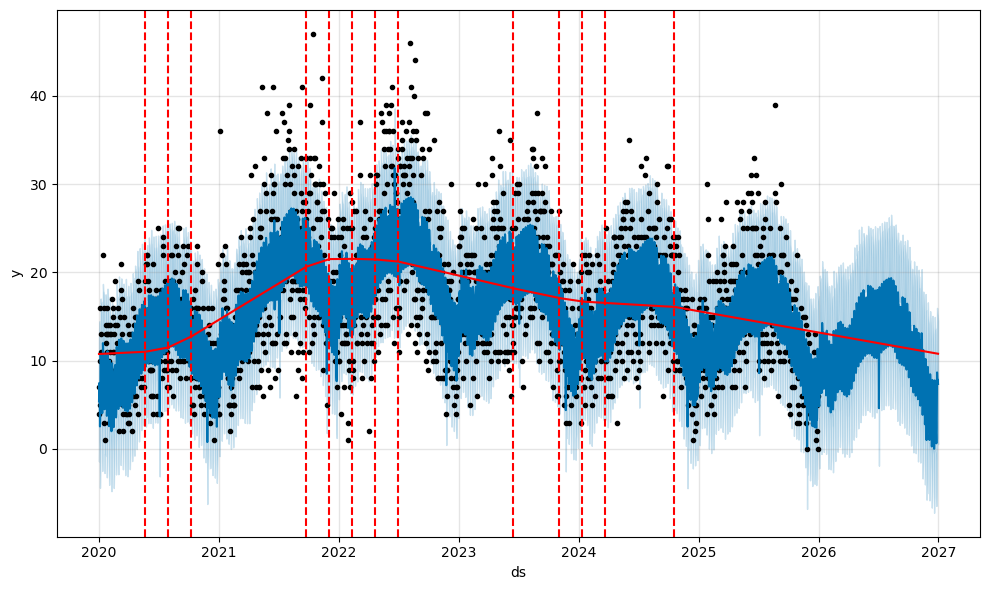

In [75]:
if not best_params:
    best_params = {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10}

m = Prophet(holidays=holidays,
            changepoint_prior_scale = best_params['changepoint_prior_scale'],
            seasonality_prior_scale = best_params['seasonality_prior_scale'])
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig1 = m.plot(forecast)
a = add_changepoints_to_plot(fig1.gca(), m, forecast)

## Cross-Validation

In [76]:
cv_period = '14 days'

forecast_horizon = '14 days'

init_days = '1996 days' # 1996 should be the right one...isn't working because we fit the model on df_train...

In [77]:
df_cv = cross_validation(m, 
                         initial=init_days, 
                         period=cv_period, 
                         horizon = forecast_horizon)

  0%|          | 0/13 [00:00<?, ?it/s]

01:39:28 - cmdstanpy - INFO - Chain [1] start processing
01:39:28 - cmdstanpy - INFO - Chain [1] done processing
01:39:28 - cmdstanpy - INFO - Chain [1] start processing
01:39:29 - cmdstanpy - INFO - Chain [1] done processing
01:39:29 - cmdstanpy - INFO - Chain [1] start processing
01:39:29 - cmdstanpy - INFO - Chain [1] done processing
01:39:29 - cmdstanpy - INFO - Chain [1] start processing
01:39:30 - cmdstanpy - INFO - Chain [1] done processing
01:39:30 - cmdstanpy - INFO - Chain [1] start processing
01:39:30 - cmdstanpy - INFO - Chain [1] done processing
01:39:30 - cmdstanpy - INFO - Chain [1] start processing
01:39:31 - cmdstanpy - INFO - Chain [1] done processing
01:39:31 - cmdstanpy - INFO - Chain [1] start processing
01:39:31 - cmdstanpy - INFO - Chain [1] done processing
01:39:31 - cmdstanpy - INFO - Chain [1] start processing
01:39:32 - cmdstanpy - INFO - Chain [1] done processing
01:39:32 - cmdstanpy - INFO - Chain [1] start processing
01:39:32 - cmdstanpy - INFO - Chain [1]

In [78]:
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,15.840563,3.980020,3.130983,0.185365,0.220375,0.880342
1,3 days,19.823440,4.452352,3.489336,0.365572,0.310851,0.811966
2,4 days,28.679751,5.355348,4.444831,0.449659,0.418735,0.713675
3,5 days,18.820815,4.338296,3.609470,0.178571,0.281770,0.914530
4,6 days,28.272305,5.317171,4.711060,0.299524,0.353319,0.833333
5,7 days,36.629588,6.052238,5.289241,0.502378,0.378007,0.658120
6,8 days,43.068658,6.562672,4.768980,0.431597,0.456542,0.782051
7,9 days,32.979296,5.742760,4.627978,0.325006,0.369792,0.790598
8,10 days,16.854818,4.105462,3.376747,0.312537,0.354168,0.880342
9,11 days,21.263683,4.611256,3.723008,0.441518,0.434311,0.811966


## Resulting Average RMSE

In [79]:
np.mean(df_p['rmse'])

5.150148424125346

# How does prophet do with predicting the 2026 data?

In [80]:
df26 = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs26.csv')
df26['created_date'] = pd.to_datetime(df26['created_date']) 
df26 = df26[df26['borough']=='MANHATTAN']

dates26 = pd.date_range('2026-01-01', '2026-02-28', freq='D')

index26 = pd.MultiIndex.from_product([['MANHATTAN'], dates26], names=['borough', 'created_date'])

df26 = df26.set_index(['borough', 'created_date']).reindex(index26).fillna({'count': 0}).reset_index()
df26['count'] = df26['count'].astype(int)
df26.drop(columns=['borough'], inplace=True)
df26 = df26.rename(columns = {'created_date' : 'ds', 'count':'y'})

df26

,ds,y
0,2026-01-01,3
1,2026-01-02,10
2,2026-01-03,9
3,2026-01-04,9
4,2026-01-05,11
5,2026-01-06,14
6,2026-01-07,17
7,2026-01-08,11
8,2026-01-09,6
9,2026-01-10,6


In [81]:
len(dates26)

59

In [82]:
forecast26 = m.make_future_dataframe(periods=len(dates26))

In [83]:
forecast26

,ds
0,2020-01-01
1,2020-01-02
2,2020-01-03
3,2020-01-04
4,2020-01-05
...,...
2246,2026-02-24
2247,2026-02-25
2248,2026-02-26
2249,2026-02-27


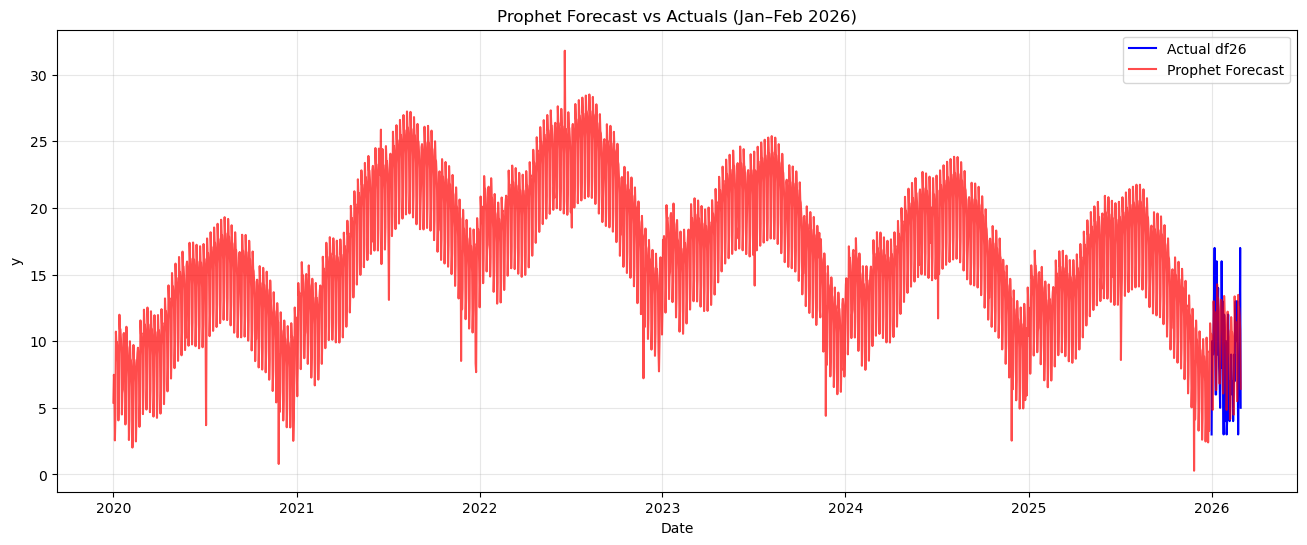

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

forecast26 = m.make_future_dataframe(periods=len(dates26))
forecast26_pred = m.predict(forecast26)

forecast_series = pd.Series(
    data=forecast26_pred['yhat'].values,
    index=pd.to_datetime(forecast26_pred['ds'])
)
df26_series = pd.Series(
    data=df26['y'].values,
    index=pd.to_datetime(df26['ds'])
)

plt.figure(figsize=(16,6))
plt.plot(df26_series.index, df26_series, label="Actual df26", color='b')
plt.plot(forecast_series.index, forecast_series, label="Prophet Forecast", color='r', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("y")
plt.title("Prophet Forecast vs Actuals (Jan–Feb 2026)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [86]:
start_date = pd.to_datetime("2026-01-01")
end_date = pd.to_datetime("2026-02-28")

forecast_aligned = forecast_series.loc[start_date:end_date]
actual_aligned = df26_series.loc[start_date:end_date]

rmse = np.sqrt(mean_squared_error(actual_aligned, forecast_aligned))
print(f"RMSE against actuals: (2026-01-01 to 2026-02-28): {rmse:.4f}")

RMSE against actuals: (2026-01-01 to 2026-02-28): 3.9296


### It does pretty good!

An RMSE of 3.9296 against the actuals is pretty good!